In [0]:
import pandas as pd 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [0]:
"""
preprocessing — day-ahead training matrix with target = alpha.
Simplified: only lag-2d/7d, no weather, big-client reclassification.
"""
from pyspark.sql import functions as F, Window
import math


# ═══════════════════════════════════════════════════════════════════════════
# STEP 0 — reclassify large clients as individual groups
# ═══════════════════════════════════════════════════════════════════════════
def reclassify_large_clients(df, top_n=10):
    """Move the top-N biggest clients (by total active_kw) into their own
    community so they are modelled individually."""
    top = (df.groupBy("client_id", "community_code")
             .agg(F.sum("active_kw").alias("_tot"))
             .orderBy(F.desc("_tot"))
             .limit(top_n))
    top_map = top.select(
        F.col("client_id"),
        F.concat(F.lit("BIG_"), F.col("client_id")).alias("_new_com"))
    out = (df.join(top_map, "client_id", "left")
             .withColumn("community_code",
                 F.when(F.col("_new_com").isNotNull(), F.col("_new_com"))
                  .otherwise(F.col("community_code")))
             .drop("_new_com"))
    n_big = top.count()
    n_groups = out.select("community_code").distinct().count()
    print(f"[reclassify] {n_big} big client(s) separated → {n_groups} total groups")
    return out


# ═══════════════════════════════════════════════════════════════════════════
# STEP 1 — panel
# ═══════════════════════════════════════════════════════════════════════════
def build_community_timestep_panel(df):
    first_seen = (df.groupBy("client_id")
                    .agg(F.min("datetime_utc").alias("_first_dt")))
    df = (df.join(first_seen, "client_id", "left")
            .withColumn("_is_new",
                        (F.col("datetime_utc") == F.col("_first_dt")).cast("int"))
            .withColumn("_is_missing", F.col("active_kw").isNull().cast("int")))
    return (
        df.groupBy("community_code", "datetime_utc")
          .agg(F.first("datetime_local").alias("datetime_local"),
               F.countDistinct("client_id").alias("n_clients"),
               F.sum("_is_missing").alias("n_missing"),
               F.sum("active_kw").alias("total_kw"))
          .withColumn("n_reporting", F.col("n_clients") - F.col("n_missing"))
    )


# ═══════════════════════════════════════════════════════════════════════════
# STEP 2 — alpha dataset (simplified: lag-2d/7d only, no weather)
# ═══════════════════════════════════════════════════════════════════════════
def build_alpha_dataset(
    raw_df,
    demand_forecast,
    holidays,
    cutoff_hour_local: int = 12,
    min_history_days: int = 28,
    top_n_clients: int = 10,
):
    # ── 0. Reclassify big clients ────────────────────────────────────────
    raw_df = reclassify_large_clients(raw_df, top_n=top_n_clients)

    # ── 1. Panel ─────────────────────────────────────────────────────────
    panel = build_community_timestep_panel(raw_df)

    # ── 2. Demand forecast join (hourly UTC) ─────────────────────────────
    D = (demand_forecast.select(
            F.date_trunc("hour", F.col("datetime_utc")).alias("_h"),
            F.col("value").alias("D_mw")))
    panel = (panel.withColumn("_h", F.date_trunc("hour", F.col("datetime_utc")))
                  .join(D, "_h", "left")
                  .drop("_h"))

    # (no weather join)

    # ── 3. Alpha ─────────────────────────────────────────────────────────
    panel = panel.withColumn(
        "alpha",
        F.when((F.col("n_clients") > 0) &
               (F.col("D_mw") > 0) &
               F.col("total_kw").isNotNull(),
               F.col("total_kw") / (F.col("n_clients") * F.col("D_mw"))))

    # ── 4. target_date + holidays ────────────────────────────────────────
    p = panel.withColumn("target_date", F.to_date("datetime_local"))
    hol_dates = holidays.select("date").distinct()
    p = (p.join(hol_dates, p["target_date"] == hol_dates["date"], "left")
         .withColumn("is_holiday", F.when(F.col("date").isNotNull(), 1).otherwise(0))
         .drop("date"))

    # ── 5. Lags (only 2d and 7d) ─────────────────────────────────────────
    X = p
    for N in (2, 7):
        name = f"alpha_lag_{N}d"
        lagged = (p.select(
            "community_code",
            (F.col("datetime_utc") + F.expr(f"INTERVAL {N} DAYS")).alias("datetime_utc"),
            F.col("alpha").alias(name)))
        X = X.join(lagged, ["community_code", "datetime_utc"], "left")

    # ── 6. Snapshot: n_clients_at_cutoff from D-1 11:45 local ────────────
    SNAP_H, SNAP_M = cutoff_hour_local - 1, 45
    snap = (p.withColumn("n_clients_at_cutoff", F.col("n_clients"))
             .filter((F.hour("datetime_local") == SNAP_H) &
                     (F.minute("datetime_local") == SNAP_M))
             .withColumn("target_date", F.date_add(F.to_date("datetime_local"), 1))
             .select("community_code", "target_date", "n_clients_at_cutoff"))
    X = X.join(snap, ["community_code", "target_date"], "left")

    # ── 7. Calendar ──────────────────────────────────────────────────────
    TAU = 2 * math.pi
    X = (X.withColumn("hour",       F.hour("datetime_local"))
          .withColumn("qhour",      (F.minute("datetime_local") / 15).cast("int"))
          .withColumn("mod",        F.col("hour") * 4 + F.col("qhour"))
          .withColumn("dow",        F.dayofweek("datetime_local"))
          .withColumn("month",      F.month("datetime_local"))
          .withColumn("doy",        F.dayofyear("datetime_local"))
          .withColumn("is_weekend", F.col("dow").isin(1, 7).cast("int"))
          .withColumn("sin_mod",    F.sin(F.lit(TAU) * F.col("mod") / 96))
          .withColumn("cos_mod",    F.cos(F.lit(TAU) * F.col("mod") / 96))
          .withColumn("sin_dow",    F.sin(F.lit(TAU) * F.col("dow") / 7))
          .withColumn("cos_dow",    F.cos(F.lit(TAU) * F.col("dow") / 7)))

    # ── 8. Label ─────────────────────────────────────────────────────────
    X = X.withColumn("y", F.col("alpha"))

    # ── 9. History filter ────────────────────────────────────────────────
    first_date = (panel.groupBy("community_code")
                       .agg(F.min(F.to_date("datetime_local")).alias("_first")))
    X = (X.join(first_date, "community_code", "left")
          .filter(F.datediff(F.col("target_date"), F.col("_first")) >= min_history_days)
          .filter(F.col("y").isNotNull())
          .drop("_first"))

    # ── 10. Project ──────────────────────────────────────────────────────
    bookkeeping = ["community_code", "target_date", "datetime_utc",
                   "datetime_local", "total_kw", "n_clients"]
    return X.select(*bookkeeping, "y", *FEATURE_COLS)


# ═══════════════════════════════════════════════════════════════════════════
# Feature catalog
# ═══════════════════════════════════════════════════════════════════════════
FEATURE_COLS = [
    "alpha_lag_2d", "alpha_lag_7d",
    "n_clients_at_cutoff", "D_mw",
    "hour", "qhour", "mod", "dow", "month", "doy", "is_weekend",
    "sin_mod", "cos_mod", "sin_dow", "cos_dow",
    "is_holiday",
]

In [0]:
df_raw   = spark.table("datathon.shared.client_consumption")
demand   = spark.table("datathon.shared.demand_forecast")
holidays = spark.table("datathon.belmonte_hunters.spain_public_holidays")

pdf = build_alpha_dataset(df_raw, demand, holidays).toPandas()
print(f"Dataset: {pdf.shape[0]:,} rows, {pdf['community_code'].nunique()} groups")
print(f"Columns: {list(pdf.columns)}")

[reclassify] 10 big client(s) separated → 28 total groups
Dataset: 783,088 rows, 28 groups
Columns: ['community_code', 'target_date', 'datetime_utc', 'datetime_local', 'total_kw', 'n_clients', 'y', 'alpha_lag_2d', 'alpha_lag_7d', 'n_clients_at_cutoff', 'D_mw', 'hour', 'qhour', 'mod', 'dow', 'month', 'doy', 'is_weekend', 'sin_mod', 'cos_mod', 'sin_dow', 'cos_dow', 'is_holiday']


In [0]:
# ── Naive baseline: pred_kw = alpha_lag_7d * n_clients_at_cutoff * D_mw ─────
from sklearn.metrics import mean_absolute_error

b = pdf.dropna(subset=["alpha_lag_7d"]).copy()
b["pred_kw"] = b["alpha_lag_7d"] * b["n_clients_at_cutoff"] * b["D_mw"]

agg = b.groupby("datetime_utc").agg(actual=("total_kw", "sum"), pred=("pred_kw", "sum"))
mae_kw = mean_absolute_error(agg["actual"], agg["pred"])

print(f"Portfolio kW MAE = {mae_kw:,.1f}")

Portfolio kW MAE = 15,105.6


In [0]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error

d = pdf.dropna(subset=["alpha_lag_7d"]).copy()
d["datetime_utc"]   = pd.to_datetime(d["datetime_utc"])
d["datetime_local"] = pd.to_datetime(d["datetime_local"])
d["target_date"]    = pd.to_datetime(d["target_date"])

# ── Baseline ────────────────────────────────────────────────────────────
d["baseline_kw"] = d["alpha_lag_7d"] * d["n_clients_at_cutoff"] * d["D_mw"]
d["y"] = d["total_kw"] - d["baseline_kw"]

# ── Date range ──────────────────────────────────────────────────────────
d0, d1 = d["target_date"].min(), d["target_date"].max()
print(f"Start: {d0.date()}  End: {d1.date()}  Span: {(d1-d0).days}d")
print(f"Groups: {d['community_code'].nunique()}")

# ── Single fold: 70% train, 7-day purge, 30% test ───────────────
train_end = pd.Timestamp("2025-08-30")
val_start = pd.Timestamp("2025-09-06")
val_end   = pd.Timestamp("2025-12-01")
print(f"Train: [d0, {train_end.date()})  Purge: 7d  Test: [{val_start.date()}, {val_end.date()})")

# ── Baseline MAE on test set ─────────────────────────────────────────
va_all = d[(d["target_date"] >= val_start) & (d["target_date"] < val_end)]
agg_base = va_all.groupby("datetime_utc").agg(actual=("total_kw", "sum"), pred=("baseline_kw", "sum"))
mae_baseline = mean_absolute_error(agg_base["actual"], agg_base["pred"])
print(f"\nBaseline MAE (test) = {mae_baseline:,.1f}")

Start: 2025-01-29  End: 2025-11-30  Span: 305d
Groups: 28
Train: [d0, 2025-08-30)  Purge: 7d  Test: [2025-09-06, 2025-12-01)

Baseline MAE (test) = 13,425.4


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 2965.58
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[4]	valid_0's l1: 688.833
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[146]	valid_0's l1: 289.492
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's l1: 338.401
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	valid_0's l1: 246.009
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[6]	valid_0's l1: 839.143
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 507.79
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[23]	valid_0's l1: 2252.43
Training until valid

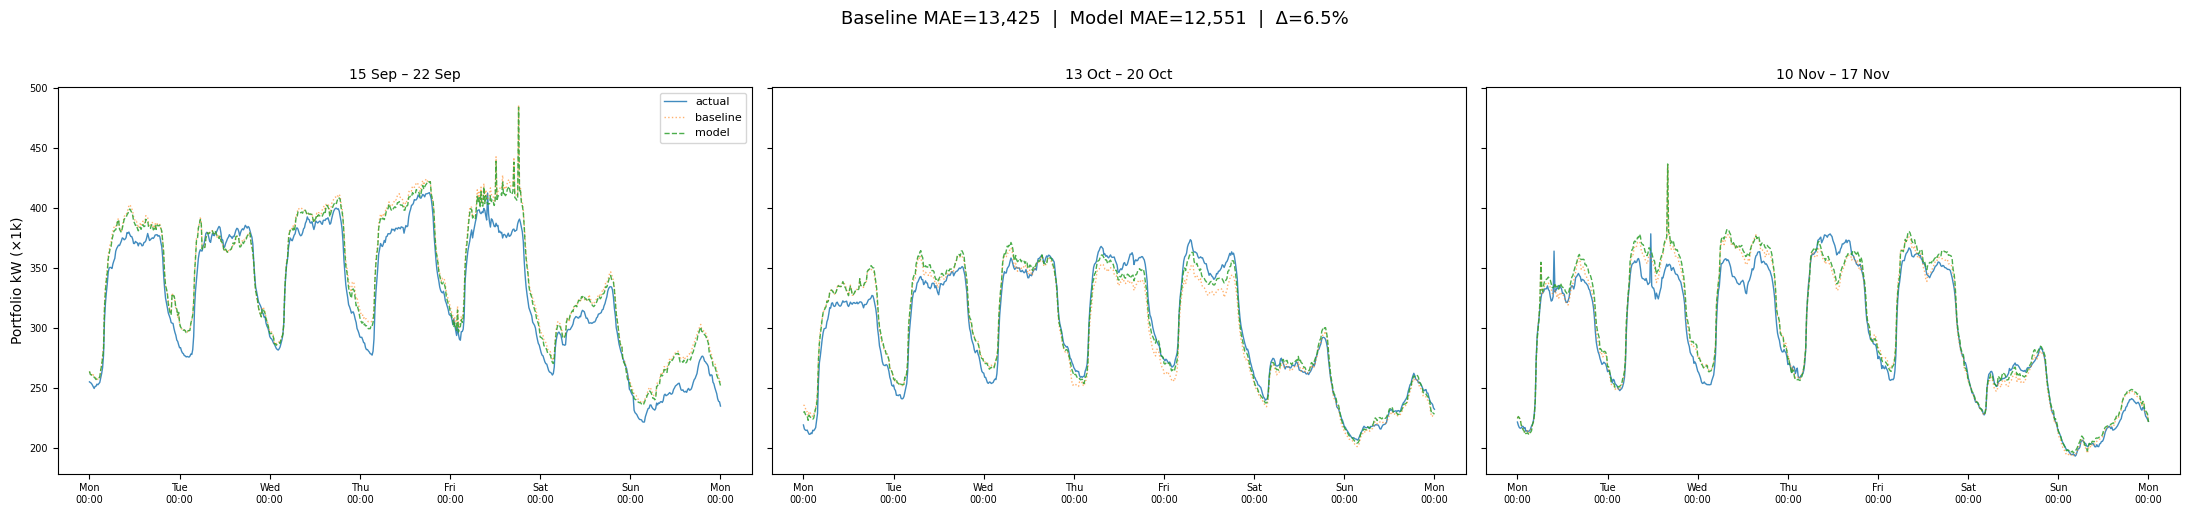

In [0]:
import lightgbm as lgb
import matplotlib.pyplot as plt, matplotlib.dates as mdates

FEATS = [
    "alpha_lag_7d", "alpha_lag_2d",
    "hour", "qhour", "mod", "dow", "month", "doy", "is_weekend",
    "sin_mod", "cos_mod", "sin_dow", "cos_dow", "is_holiday",
]
CATS = ["hour", "qhour", "dow", "month", "is_weekend", "is_holiday"]
for c in CATS:
    d[c] = d[c].astype("category")

PARAMS = dict(
    objective="regression_l1", metric="mae",
    learning_rate=0.05, num_leaves=31, min_data_in_leaf=200,
    n_estimators=500, verbose=-1,
)

# ── Per-community LightGBM on residual ──────────────────────────────
communities = sorted(d["community_code"].unique())
rows = []
for com in communities:
    sub = d[d["community_code"] == com]
    tr  = sub[sub["target_date"] < train_end]
    va  = sub[(sub["target_date"] >= val_start) & (sub["target_date"] < val_end)]
    if len(va) == 0:
        continue
    v = va[["datetime_utc", "community_code", "baseline_kw", "total_kw"]].copy()
    if len(tr) < 500:
        v["pred_kw"] = v["baseline_kw"]
        rows.append(v)
        continue
    m = lgb.LGBMRegressor(**PARAMS)
    m.fit(
        tr[FEATS], tr["y"],
        eval_set=[(va[FEATS], va["y"])],
        categorical_feature=CATS,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )
    v["pred_kw"] = v["baseline_kw"] + m.predict(va[FEATS])
    rows.append(v)

result = pd.concat(rows, ignore_index=True)
agg = (result.groupby("datetime_utc")
       .agg(actual=("total_kw", "sum"),
            baseline=("baseline_kw", "sum"),
            pred=("pred_kw", "sum"))
       .sort_index())

mae_base  = mean_absolute_error(agg["actual"], agg["baseline"])
mae_model = mean_absolute_error(agg["actual"], agg["pred"])
print(f"Baseline MAE = {mae_base:,.1f}")
print(f"Model MAE    = {mae_model:,.1f}")
print(f"Improvement  = {mae_base - mae_model:,.1f} ({(1 - mae_model/mae_base)*100:.1f}%)")

# ── Plot sample weeks from test set ─────────────────────────────────
week_starts = [
    pd.Timestamp("2025-09-15"),
    pd.Timestamp("2025-10-13"),
    pd.Timestamp("2025-11-10"),
]
fig, axes = plt.subplots(1, len(week_starts), figsize=(22, 5), sharey=True)
for j, ws in enumerate(week_starts):
    we = ws + pd.Timedelta(days=7)
    c = agg.loc[ws:we]
    ax = axes[j]
    ax.plot(c.index, c["actual"]   / 1e3, lw=1, alpha=0.85, label="actual")
    ax.plot(c.index, c["baseline"] / 1e3, lw=1, alpha=0.6,  label="baseline", ls=":")
    ax.plot(c.index, c["pred"]     / 1e3, lw=1, alpha=0.85, label="model", ls="--")
    ax.set_title(f"{ws.strftime('%d %b')} \u2013 {we.strftime('%d %b')}", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.set_ylabel("Portfolio kW (\u00d71k)", fontsize=10)
        ax.legend(fontsize=8)

fig.suptitle(f"Baseline MAE={mae_base:,.0f}  |  Model MAE={mae_model:,.0f}  |  \u0394={(1-mae_model/mae_base)*100:.1f}%",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [0]:
# ── Per-community LightGBM on alpha residual (alpha - alpha_lag_7d) ───────
alpha_actual = d["total_kw"] / (d["n_clients"] * d["D_mw"])
d["y_alpha"] = alpha_actual - d["alpha_lag_7d"]

rows_a = []
for com in communities:
    sub = d[d["community_code"] == com]
    tr  = sub[sub["target_date"] < train_end]
    va  = sub[(sub["target_date"] >= val_start) & (sub["target_date"] < val_end)]
    if len(va) == 0:
        continue
    v = va[["datetime_utc", "community_code", "alpha_lag_7d",
            "n_clients_at_cutoff", "D_mw", "total_kw", "baseline_kw"]].copy()
    if len(tr) < 500:
        v["pred_kw"] = v["baseline_kw"]
        rows_a.append(v); continue
    m = lgb.LGBMRegressor(**PARAMS)
    m.fit(
        tr[FEATS], tr["y_alpha"],
        eval_set=[(va[FEATS], va["y_alpha"])],
        categorical_feature=CATS,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )
    pred_alpha = va["alpha_lag_7d"] + m.predict(va[FEATS])
    v["pred_kw"] = pred_alpha * v["n_clients_at_cutoff"] * v["D_mw"]
    rows_a.append(v)

result_a = pd.concat(rows_a, ignore_index=True)
agg_a = (result_a.groupby("datetime_utc")
         .agg(actual=("total_kw", "sum"),
              baseline=("baseline_kw", "sum"),
              pred=("pred_kw", "sum"))
         .sort_index())

mae_base_a  = mean_absolute_error(agg_a["actual"], agg_a["baseline"])
mae_model_a = mean_absolute_error(agg_a["actual"], agg_a["pred"])

print("Residual of kW   (prev cell):")
print(f"  Baseline MAE = {mae_base:,.1f}   Model MAE = {mae_model:,.1f}   \u0394={(1-mae_model/mae_base)*100:.1f}%")
print("Residual of alpha (this cell):")
print(f"  Baseline MAE = {mae_base_a:,.1f}   Model MAE = {mae_model_a:,.1f}   \u0394={(1-mae_model_a/mae_base_a)*100:.1f}%")

# ── Plot comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(week_starts), figsize=(22, 5), sharey=True)
for j, ws in enumerate(week_starts):
    we = ws + pd.Timedelta(days=7)
    c = agg_a.loc[ws:we]
    ax = axes[j]
    ax.plot(c.index, c["actual"]   / 1e3, lw=1, alpha=0.85, label="actual")
    ax.plot(c.index, c["baseline"] / 1e3, lw=1, alpha=0.6,  label="baseline", ls=":")
    ax.plot(c.index, c["pred"]     / 1e3, lw=1, alpha=0.85, label="model (\u03b1 resid)", ls="--")
    ax.set_title(f"{ws.strftime('%d %b')} \u2013 {we.strftime('%d %b')}", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.set_ylabel("Portfolio kW (\u00d71k)", fontsize=10)
        ax.legend(fontsize=8)
fig.suptitle(f"Alpha-residual: Baseline={mae_base_a:,.0f}  |  Model={mae_model_a:,.0f}  |  \u0394={(1-mae_model_a/mae_base_a)*100:.1f}%",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 8.35604e-05


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:139)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:139)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:724)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:442)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:442)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

In [0]:
# ── Winter-month baseline: original vs big-client reclassification ──────
from sklearn.metrics import mean_absolute_error

WINTER = [12, 1, 2]

# --- Reclassified (28 groups): winter in TRAIN ---
d_train = d[d["target_date"] < train_end]
d_winter = d_train[d_train["datetime_utc"].dt.month.isin(WINTER)]
agg_r = d_winter.groupby("datetime_utc").agg(
    actual=("total_kw", "sum"), pred=("baseline_kw", "sum"))
mae_r = mean_absolute_error(agg_r["actual"], agg_r["pred"])

# --- Original (18 communities): winter in TRAIN ---
o = pdf_orig.dropna(subset=["alpha_lag_7d"]).copy()
o["datetime_utc"] = pd.to_datetime(o["datetime_utc"])
o["target_date"]  = pd.to_datetime(o["target_date"])
o["baseline_kw"]  = o["alpha_lag_7d"] * o["n_clients_at_cutoff"] * o["D_mw"]
o_train  = o[o["target_date"] < train_end]
o_winter = o_train[o_train["datetime_utc"].dt.month.isin(WINTER)]
agg_o = o_winter.groupby("datetime_utc").agg(
    actual=("total_kw", "sum"), pred=("baseline_kw", "sum"))
mae_o = mean_absolute_error(agg_o["actual"], agg_o["pred"])

print(f"Winter months (Dec, Jan, Feb) — training period only")
print(f"  Timesteps: {len(agg_o):,} (orig)  {len(agg_r):,} (reclass)")
print(f"  Baseline MAE (original 18 communities)  = {mae_o:,.1f}")
print(f"  Baseline MAE (28 groups, big clients)    = {mae_r:,.1f}")
print(f"  Difference: {mae_o - mae_r:,.1f}  ({(mae_o - mae_r)/mae_o*100:+.1f}%)")

Winter months (Dec, Jan, Feb) — training period only
  Timesteps: 2,980 (orig)  2,980 (reclass)
  Baseline MAE (original 18 communities)  = 12,623.6
  Baseline MAE (28 groups, big clients)    = 12,500.8
  Difference: 122.9  (+1.0%)


In [0]:
# ── Compare baseline MAE: original communities vs big-client reclassification ──
from sklearn.metrics import mean_absolute_error

# Original communities (from pre-built table, no reclassification)
pdf_orig = spark.table("datathon.belmonte_hunters.alpha_dataset").toPandas()
pdf_orig["datetime_utc"] = pd.to_datetime(pdf_orig["datetime_utc"])
pdf_orig["target_date"]  = pd.to_datetime(pdf_orig["target_date"])
o = pdf_orig.dropna(subset=["alpha_lag_7d"]).copy()
o["baseline_kw"] = o["alpha_lag_7d"] * o["n_clients_at_cutoff"] * o["D_mw"]
o_test = o[(o["target_date"] >= val_start) & (o["target_date"] < val_end)]
agg_orig = o_test.groupby("datetime_utc").agg(actual=("total_kw", "sum"), pred=("baseline_kw", "sum"))
mae_orig = mean_absolute_error(agg_orig["actual"], agg_orig["pred"])

# Reclassified communities (already computed in cell 5)
mae_reclass = mae_baseline  # from cell 5

print(f"Baseline MAE (original 18 communities)          = {mae_orig:,.1f}")
print(f"Baseline MAE (28 groups: 18 com + 10 big clients) = {mae_reclass:,.1f}")
print(f"Difference: {mae_orig - mae_reclass:,.1f}  ({(mae_orig - mae_reclass)/mae_orig*100:+.1f}%)")

Baseline MAE (original 18 communities)          = 13,855.4
Baseline MAE (28 groups: 18 com + 10 big clients) = 13,425.4
Difference: 430.0  (+3.1%)
